# COM-304 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

---

## 1 Setup

Please follow the setup detailed in the first notebook.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/opt/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xL40 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/maskgit_mnist_loss_curves.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 13, 13, 13, 13, 10, 10, 10, 23,
         10, 14, 22, 10, 10, 10, 14, 21, 10, 10, 10, 10, 10, 10, 10, 25, 12, 10,
         10, 10, 25, 25, 17, 18, 10, 10, 10, 10, 10, 10, 10, 10]])

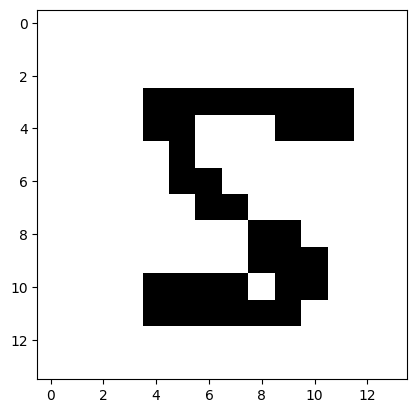

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

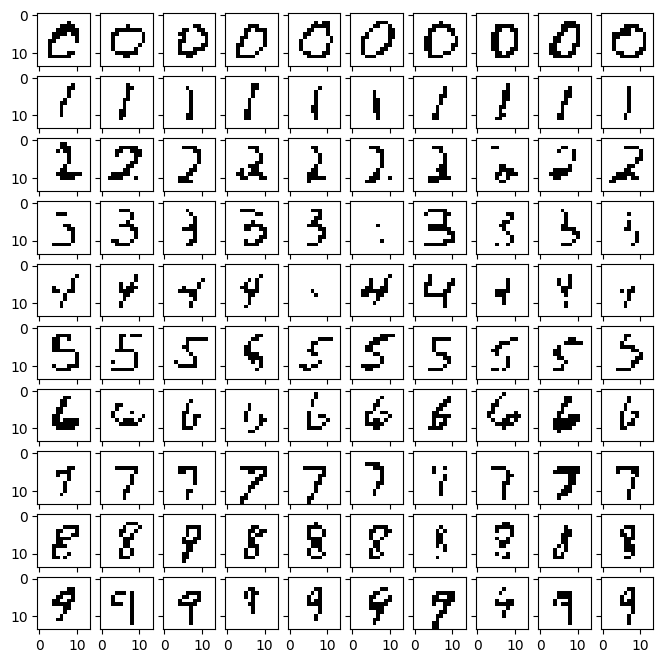

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

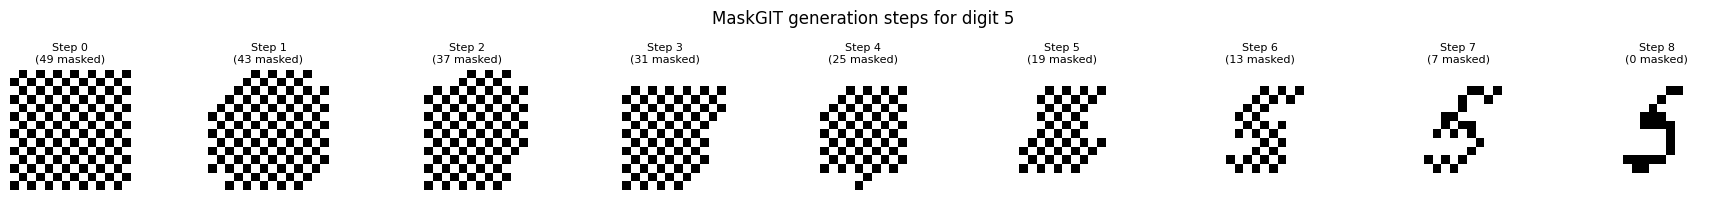


Observations:
- At step 0, the image is essentially random noise since all image tokens are masked.
- At each subsequent step, the model unmasks the most confident tokens first.
- The overall structure (e.g., the rough shape of the digit) emerges in the early steps, 
  while later steps refine finer details and edges.
- This is in contrast to autoregressive generation which generates in a fixed raster-scan order;
  here the model can generate spatially distant tokens in the same step if it is confident about them.
- The non-sequential generation order shows the model's ability to reason globally about the image.



In [7]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(seq, mask, num_steps=8, temp=0.7, top_p=0.9, return_history=True)

fig, axes = plt.subplots(1, seq_history.shape[0], figsize=(2 * seq_history.shape[0], 2))
for i in range(seq_history.shape[0]):
    reconst = detokenize_MNIST(seq_history[i:i+1], patch_size=2, account_for_labels=True).cpu()
    n_masked = mask_history[i].sum().item()
    axes[i].imshow(reconst[0], cmap='gray_r')
    axes[i].set_title(f'Step {i}\n({int(n_masked)} masked)', fontsize=8)
    axes[i].axis('off')
plt.suptitle(f'MaskGIT generation steps for digit {label}', fontsize=12)
plt.tight_layout()
plt.show()

print("""
Observations:
- At step 0, the image is essentially random noise since all image tokens are masked.
- At each subsequent step, the model unmasks the most confident tokens first.
- The overall structure (e.g., the rough shape of the digit) emerges in the early steps, 
  while later steps refine finer details and edges.
- This is in contrast to autoregressive generation which generates in a fixed raster-scan order;
  here the model can generate spatially distant tokens in the same step if it is confident about them.
- The non-sequential generation order shows the model's ability to reason globally about the image.
""")

#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?


--- num_steps = 1 ---


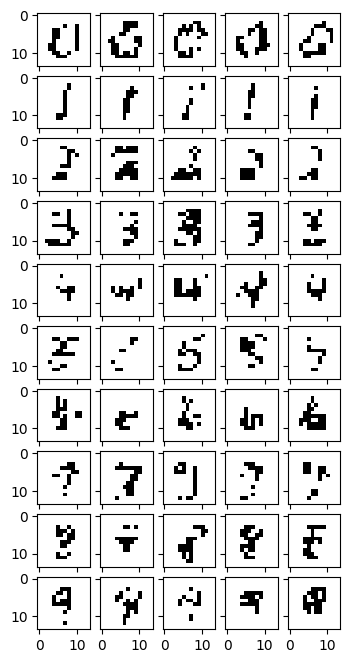


--- num_steps = 4 ---


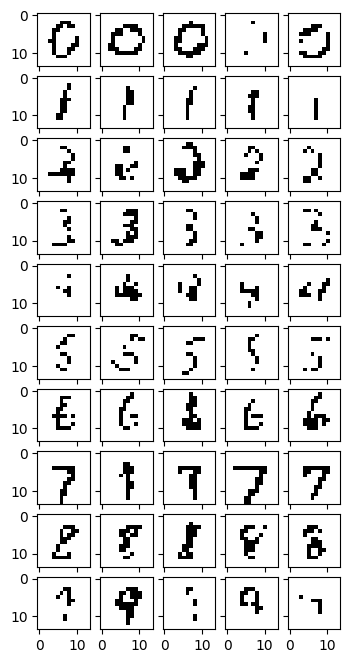


--- num_steps = 8 ---


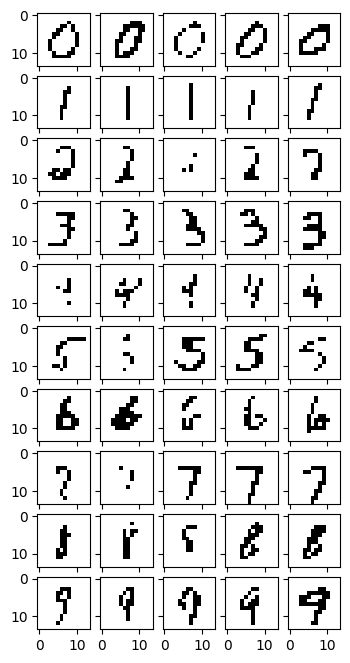


--- num_steps = 16 ---


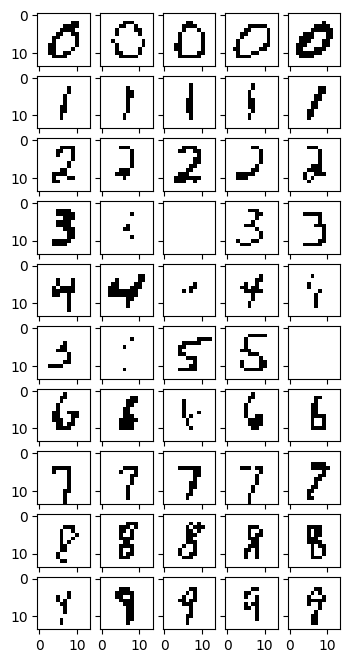


--- num_steps = 32 ---


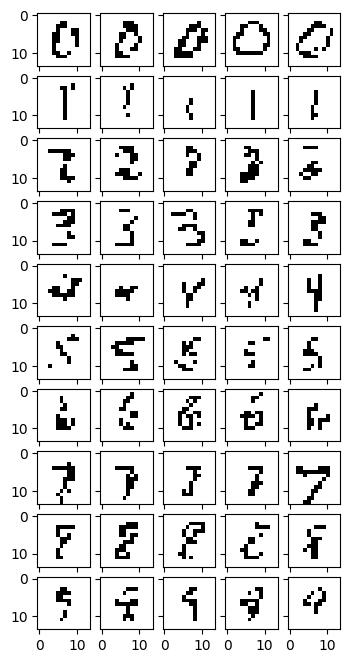


--- num_steps = 49 ---


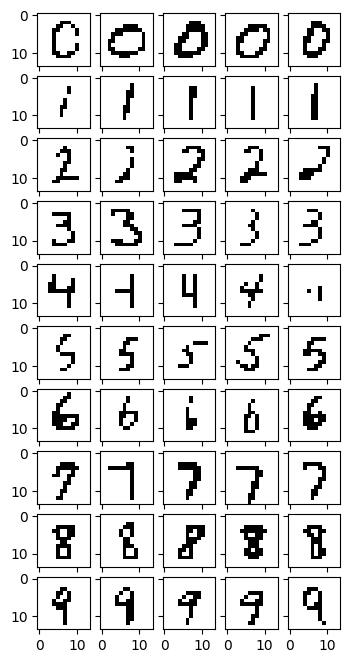


Observations:
- k=1 (single step): The model generates all tokens in a single pass. The quality is noticeably 
  worse, with many malformed digits, since the model cannot iteratively refine its predictions.
- k=4: Quality improves significantly as the model gets a few rounds to refine predictions.
- k=8 (default): Good balance between quality and speed. Most digits are recognizable.
- k=16, 32: Quality continues to improve slightly with more steps but with diminishing returns.
- k=49: Each step unmasks roughly one token. This is the most sequential and slowest, but produces 
  the highest quality since the model has maximum information at each step. However, the improvement 
  over k=8 or k=16 is marginal.
- The key insight is that MaskGIT can trade off speed vs quality by adjusting the number of steps.
  Even with relatively few steps (k=4-8), the results are already quite good, which is a major 
  advantage over autoregressive models that always require L sequential steps.



In [8]:
for k in [1, 4, 8, 16, 32, 49]:
    print(f"\n--- num_steps = {k} ---")
    generate_samples(model, num_steps=k, temp=0.7, top_p=0.9, top_k=0.0, n_samples=5)

print("""
Observations:
- k=1 (single step): The model generates all tokens in a single pass. The quality is noticeably 
  worse, with many malformed digits, since the model cannot iteratively refine its predictions.
- k=4: Quality improves significantly as the model gets a few rounds to refine predictions.
- k=8 (default): Good balance between quality and speed. Most digits are recognizable.
- k=16, 32: Quality continues to improve slightly with more steps but with diminishing returns.
- k=49: Each step unmasks roughly one token. This is the most sequential and slowest, but produces 
  the highest quality since the model has maximum information at each step. However, the improvement 
  over k=8 or k=16 is marginal.
- The key insight is that MaskGIT can trade off speed vs quality by adjusting the number of steps.
  Even with relatively few steps (k=4-8), the results are already quite good, which is a major 
  advantage over autoregressive models that always require L sequential steps.
""")

---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [9]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [10]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xL40s node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/maskgit_tinystories_loss_curves.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [11]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [12]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Once was a boy, named Peter. Peter always up to out to he used on the wood, so he went to an old wood place it to.
was walking and soon some pieces stones on of wood wood made. Peter he got cutting wood wood to had to work further and make the wood look better.
Finally, the wood looked were as and they. It his best size just the perfect the same. Peter was disappointed proud and he was into the end he had been with the before.

Then he opened the door of wood and it was like the was'd been He had made the wood look as good as before. But when Peter went back, he saw that he had also there to take. The made now from home all the of wood wood. Peter was very sad. He

" started to break the wood and play with," said Peter, "Today one is left on it with me." Peter

That happened, he's dad came back. The woods had came over and they Peter was sorry. they had lost the perfect wood he found out. He had realized the wood was broken. Peter was feeling very sad but and knew Peter would never for

Onceily was Tom were friends. They liked to play in the park. One day, they found a big orange ball and ran. It was round and round and had and white shape on

They decided to throw it under to another place to the shed. They ran after and reached it. But it the ball rolled towards the fence. They hit sad and dropped and knocked over They both cried and

The other broke them the fence. It pushed everything the fence landed on the fence and the grass. They were a big. Her were falling a lot of the hair. their hair came to and saw. She saw their faces and their hair. She said they Lily and Tom could they hurt them. They felted and felt ashamed.

They looked at each other. They saw their feet under a tree. They wished they had been a bit away, They wished they had shared their same ball to each with the. They forgot their lesson. The neighbor had helped them and a hug.

Their was Dad, lady. She had a big smile that said, "To Max and Tom and Tom and Lily have Lily". She wanted them to be h

Once there was a little boy which Tim. He was three bored and Tim liked feeling happy, but he did to feel something funny about it He opened into the kitchen and saw an old woman on the dresser. He noticed wearing an old dress, and she looked very hungry.

The walked walked to Tim, and asked what "Who are you here?"

Tim smiled, "Hello there! I am a to help you.

The old woman chuckled and asked him,What do you think me to help you?"

Tim was confused that said.
's think kind of questions around this house. You can try to help it."."

The woman smiled and said, "Sure,

So, the woman then followed Tim to his kitchen. Tim there, some time vegetables and he finished't. his mom said, "And you can to count, Iheart will

Together, Tim smiled his head was proud. He was so longer confused, and he knew the lady could help him. a few minutes he the woman rose up the window as it came across from the houseer and put in the new dresser. 's mom smiled and said, "See, I told help you."

Tim smiled, 

Once day, a rich man who wanted to build a pipe. His mom asked to help him but she was too small. She said they were going to build a pipe in one, but the old man got't ask. He was feeling unhappy and frustrated.

The rich saw that little girl felt sad. She asked him she wanted to help, but he didn busy a So the the rich let it mom buy at home store. He hoped building their pipe by his mom and her help.

The a bigger week to to build the strange pipe. But its young girl was still happy, and the rich man was very happy and the that the were so much cooler too. They the girl lived there all the years.


The poor man was very too. because he knew the little girl a good care in the village. From that day on, the rich boy helped her build a pipe again

--------------------------------------------------



One upon a time, was a modern clock. It was small and white. So looked all and the until the sun disappeared.

One day, a little girl along and saw it!. She was so and touched ran away the clock! and the little girl laughed away. scared the little was alone and ran away.. The girl never saw the clock forever.

The end.

--------------------------------------------------



### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [13]:
seq = torch.zeros(256, dtype=torch.long, device=device)
mask = torch.ones(256, dtype=torch.bool, device=device)

seq_history, mask_history = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=True)

display_steps = [0, 16, 32, 64, 96, 128]
for step_idx in display_steps:
    n_masked = mask_history[step_idx].sum().item()
    text = token_ids_to_text(seq_history[step_idx], text_tokenizer=tokenizer)
    print(f"--- Step {step_idx} ({int(n_masked)} masked tokens) ---")
    print(text[:300])
    print()

print("""
Observations:
- At step 0, the text is pure gibberish because all tokens are masked and the sequence 
  is initialized with zeros.
- In early steps, the model fills in the most confident tokens first, which tend to be common 
  words and structural elements (e.g., punctuation, articles, common verbs).
- As more tokens are revealed, the model gains context and subsequent predictions become 
  more coherent.
- Unlike autoregressive generation, tokens are not filled in left-to-right. Instead, 
  the model may fill in tokens at scattered positions throughout the sequence.
- The text gradually becomes more coherent over the steps, but the non-sequential filling 
  order means that early versions can have grammatically correct fragments interspersed 
  with incoherent segments.
""")

--- Step 0 (256 masked tokens) ---
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

--- Step 16 (224 masked tokens) ---
Once upon a time, there was a little girl. She was so in her garden with a delicate in her hand. when she reached the tiny touch,!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

--- Step 32 (192 masked tokens) ---
Once upon a time, there was a little girl. She was so in her garden with a delicate in her hand. when she reached the tiny touch, she was amazed excited to the beauty of the sunlight. She was so close and beautiful.

Suddenly girl stopped something too closely, she saw see something!!!!!!!!!!!!!!!!!

--- Step 64 (128 masked tokens)

#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=128`, but how does generation with `k` = 1, 16, 32, 64, 256 perform? What do you observe?

In [ ]:
for k in [1, 16, 32, 64, 256]:
    print(f"\n{'='*60}")
    print(f"num_steps = {k}")
    print(f"{'='*60}")
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=k, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))

print("""
Observations:
- k=1: All 256 tokens are generated in a single forward pass. The text is mostly incoherent,
  consisting of disconnected words and phrases. Without iterative refinement, the model
  cannot maintain consistency across the full sequence.
- k=16: Some structure emerges with short coherent phrases, but the overall narrative
  remains fragmented. Each step unmasks ~16 tokens, giving limited refinement.
- k=32: Noticeably better quality. Coherent sentences appear with more natural word order.
  The model has enough iterations to build local consistency.
- k=64: Further improvement with better narrative flow and longer-range coherence.
  Approaching the default k=128 quality.
- k=256: Each step unmasks only 1 token, making it nearly sequential. Produces the most
  coherent text, but the quality is still lower than autoregressive generation due to
  bidirectional (non-causal) attention lacking the strict left-to-right conditioning.
- The text quality improvement from more steps is much more pronounced for text than for images,
  because language has strong sequential dependencies that benefit from iterative refinement.
""")

#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

In [15]:
print("""
Comparison of nanoMaskGIT vs nanoGPT for text generation:

QUALITY:
- nanoGPT (autoregressive) produces noticeably more coherent and fluent text. Each token is 
  generated conditioned on all previous tokens, which naturally maintains left-to-right consistency.
- nanoMaskGIT generates text that tends to be less coherent, especially over longer sequences.
  Since all tokens are predicted in parallel (at each step), maintaining global consistency 
  is harder. The text often contains repetitions and non-sequiturs.

FAILURE MODES of MaskGIT for text:
- Repetition: The model often generates repetitive phrases or sentences.
- Inconsistency: Characters, names, and plot elements may contradict each other across 
  different parts of the generated text.
- Fragmentation: The text can feel like a collection of plausible fragments rather than 
  a coherent narrative.
- Poor long-range dependencies: Since the model fills tokens in a non-sequential order, 
  it struggles with maintaining consistent narrative flow.

BENEFITS of MaskGIT:
- Speed: MaskGIT can generate all tokens in far fewer steps than autoregressive models. 
  For images (e.g., MNIST), we can generate a full 49-token image in just 8 steps, whereas 
  an autoregressive model needs 49 sequential steps. This is a ~6x speedup.
- Flexible generation order: The model can generate the most confident tokens first, 
  regardless of position, which can be advantageous for structured data like images.
- Infilling: MaskGIT naturally supports infilling/inpainting, where some tokens are given 
  and the rest must be generated. This is harder with autoregressive models.
- Bidirectional context: Each prediction can attend to all non-masked tokens (both before 
  and after), providing richer context than the left-only context of autoregressive models.

THOUGHTS ON IMPROVING MASKED TEXT GENERATION:
- Use more decoding steps (closer to sequence length) for better quality, at the cost of speed.
- Implement a cosine or adaptive schedule instead of constant, to allocate more steps to 
  the "difficult" middle phase of generation.
- Use techniques from LLaDA (Large Language Diffusion Architecture) which apply diffusion-like 
  noise schedules to masked language models for better text quality.
- Combine masked and autoregressive approaches, e.g., generate an initial draft with MaskGIT 
  and then refine autoregressively.
- For images and other structured data, masked generation remains very competitive and 
  often preferred due to the speed advantage. For text, autoregressive models are still 
  generally superior, though recent work like LLaDA is closing the gap.
""")


Comparison of nanoMaskGIT vs nanoGPT for text generation:

QUALITY:
- nanoGPT (autoregressive) produces noticeably more coherent and fluent text. Each token is 
  generated conditioned on all previous tokens, which naturally maintains left-to-right consistency.
- nanoMaskGIT generates text that tends to be less coherent, especially over longer sequences.
  Since all tokens are predicted in parallel (at each step), maintaining global consistency 
  is harder. The text often contains repetitions and non-sequiturs.

FAILURE MODES of MaskGIT for text:
- Repetition: The model often generates repetitive phrases or sentences.
- Inconsistency: Characters, names, and plot elements may contradict each other across 
  different parts of the generated text.
- Fragmentation: The text can feel like a collection of plausible fragments rather than 
  a coherent narrative.
- Poor long-range dependencies: Since the model fills tokens in a non-sequential order, 
  it struggles with maintaining consisten

## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)